In [10]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
from io import StringIO

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.autolayout": True})

OUTPUT_DIR = "/kaggle/working/charts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Inline sample data (no CSV file needed) ───────────────────────────────────
RAW_CSV = """date,region,product,sales,units,customer_age,customer_gender,discount_pct,returned
2024-01-03,North,Laptop,1200.50,1,34,Male,5,No
2024-01-05,South,Phone,850.00,2,28,Female,10,No
2024-01-07,East,Tablet,,1,45,Male,0,No
2024-01-09,West,Laptop,1350.00,1,52,Female,15,No
2024-01-11,North,Phone,920.00,3,23,Male,10,Yes
2024-01-13,South,Headphones,200.00,5,31,Female,0,No
2024-01-15,East,Laptop,,1,40,Male,5,No
2024-01-17,West,Phone,780.00,2,29,Female,0,No
2024-01-19,North,Tablet,450.00,1,55,Male,20,No
2024-01-21,South,Laptop,1100.00,1,38,Female,5,Yes
2024-02-02,East,Headphones,180.00,4,26,Male,0,No
2024-02-04,West,Tablet,500.00,2,33,Female,10,No
2024-02-06,North,Phone,,1,47,Male,15,No
2024-02-08,South,Laptop,1250.00,1,60,Female,0,No
2024-02-10,East,Phone,860.00,2,22,Male,5,No
2024-02-12,West,Headphones,210.00,3,35,Female,0,Yes
2024-02-14,North,Laptop,1400.00,1,41,Male,10,No
2024-02-16,South,Tablet,430.00,1,27,Female,0,No
2024-02-18,East,Phone,900.00,4,50,Male,20,No
2024-02-20,West,Laptop,,1,36,Female,5,No
2024-03-01,North,Headphones,195.00,6,30,Male,0,No
2024-03-03,South,Phone,810.00,2,24,Female,10,Yes
2024-03-05,East,Laptop,1300.00,1,43,Male,5,No
2024-03-07,West,Tablet,,2,58,Female,15,No
2024-03-09,North,Phone,870.00,3,32,Male,0,No
2024-03-11,South,Laptop,1150.00,1,39,Female,5,No
2024-03-13,East,Headphones,220.00,4,25,Male,10,No
2024-03-15,West,Phone,950.00,2,46,Female,0,No
2024-03-17,North,Tablet,480.00,1,53,Male,20,Yes
2024-03-19,South,Laptop,1320.00,1,37,Female,0,No
2024-04-01,East,Phone,830.00,2,28,Male,5,No
2024-04-03,West,Headphones,,5,31,Female,0,No
2024-04-05,North,Laptop,1280.00,1,44,Male,10,No
2024-04-07,South,Tablet,510.00,2,26,Female,5,No
2024-04-09,East,Phone,890.00,3,49,Male,0,No
2024-04-11,West,Laptop,1380.00,1,35,Female,15,Yes
2024-04-13,North,Headphones,205.00,4,23,Male,0,No
2024-04-15,South,Phone,840.00,2,57,Female,10,No
2024-04-17,East,Tablet,460.00,1,42,Male,5,No
2024-04-19,West,Laptop,,1,30,Female,0,No"""

In [11]:
# LOAD DATA 
def load_data() -> pd.DataFrame:
    print("\n" + "=" * 55)
    print("  STEP 1 · LOAD DATA")
    print("=" * 55)

    df = pd.read_csv(StringIO(RAW_CSV), parse_dates=["date"])
    print(f"  ✔  Loaded {len(df):,} rows × {len(df.columns)} columns")
    print(f"  Columns: {list(df.columns)}\n")
    print(df.head(5).to_string(index=False))
    return df


#  CLEAN DATA 
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    print("\n" + "=" * 55)
    print("  STEP 2 · CLEAN DATA")
    print("=" * 55)

    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"\n  Missing values before cleaning:")
    print(missing.to_string())

    median_by_product = df.groupby("product")["sales"].transform("median")
    filled_count = df["sales"].isnull().sum()
    df["sales"] = df["sales"].fillna(median_by_product)
    print(f"\n  ✔  Filled {filled_count} missing 'sales' values with per-product median")

    units_filled = df["units"].isnull().sum()
    df["units"] = df["units"].fillna(1).astype(int)
    print(f"  ✔  Filled {units_filled} missing 'units' values with 1")

    df["revenue"]     = df["sales"] * df["units"] * (1 - df["discount_pct"] / 100)
    df["month"]       = df["date"].dt.to_period("M").astype(str)
    df["is_returned"] = df["returned"].map({"Yes": True, "No": False})

    print(f"\n  Missing values after cleaning: {df.isnull().sum().sum()}")
    print(f"  ✔  Added derived columns: revenue, month, is_returned")
    return df

In [12]:
# SUMMARY STATISTICS
def summary_statistics(df: pd.DataFrame) -> None:
    print("\n" + "=" * 55)
    print("  STEP 3 · SUMMARY STATISTICS")
    print("=" * 55)

    num_cols = ["sales", "units", "discount_pct", "revenue"]
    print("\n  [A] Numeric overview:")
    print(df[num_cols].describe().round(2).to_string())

    print("\n  [B] Revenue by product (NumPy):")
    for product, grp in df.groupby("product")["revenue"]:
        arr = grp.values
        print(f"    {product:<12}  total={np.sum(arr):>8,.2f}  "
              f"mean={np.mean(arr):>7,.2f}  std={np.std(arr):>7,.2f}")

    print("\n  [C] Revenue by region:")
    region_rev = (df.groupby("region")["revenue"]
                    .agg(total="sum", mean="mean", orders="count")
                    .sort_values("total", ascending=False))
    print(region_rev.round(2).to_string())

    return_rate = df["is_returned"].mean() * 100
    print(f"\n  [D] Overall return rate: {return_rate:.1f}%")

    print("\n  [E] Monthly revenue trend:")
    monthly = df.groupby("month")["revenue"].sum().reset_index()
    for _, row in monthly.iterrows():
        bar = "█" * int(row["revenue"] / 500)
        print(f"    {row['month']}  {bar}  ${row['revenue']:,.2f}")


#  VISUALIZATIONS 
def create_charts(df: pd.DataFrame) -> None:
    print("\n" + "=" * 55)
    print("  STEP 4 · CHARTS")
    print("=" * 55)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Sales Data Analysis Dashboard", fontsize=16, fontweight="bold")

    # Bar: Revenue by Product
    ax1 = axes[0, 0]
    prod_rev = df.groupby("product")["revenue"].sum().sort_values(ascending=False)
    bars = ax1.bar(prod_rev.index, prod_rev.values,
                   color=sns.color_palette("muted", len(prod_rev)))
    ax1.set_title("Total Revenue by Product")
    ax1.set_xlabel("Product"); ax1.set_ylabel("Revenue ($)")
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    for bar, val in zip(bars, prod_rev.values):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"${val:,.0f}", ha="center", va="bottom", fontsize=8)

    # Line: Monthly Trend
    ax2 = axes[0, 1]
    monthly = df.groupby("month")["revenue"].sum()
    ax2.plot(monthly.index, monthly.values, marker="o", linewidth=2,
             color=sns.color_palette("muted")[1], markersize=7)
    ax2.fill_between(monthly.index, monthly.values, alpha=0.15,
                     color=sns.color_palette("muted")[1])
    ax2.set_title("Monthly Revenue Trend")
    ax2.set_xlabel("Month"); ax2.set_ylabel("Revenue ($)")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax2.tick_params(axis="x", rotation=30)

    # Pie: Revenue by Region
    ax3 = axes[1, 0]
    region_rev = df.groupby("region")["revenue"].sum()
    ax3.pie(region_rev.values, labels=region_rev.index,
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("pastel", len(region_rev)))
    ax3.set_title("Revenue Share by Region")

    # Box: Sales Distribution
    ax4 = axes[1, 1]
    order = df.groupby("product")["sales"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x="product", y="sales", order=order,
                hue="product", palette="muted", legend=False, ax=ax4)
    ax4.set_title("Sales Distribution by Product")
    ax4.set_xlabel("Product"); ax4.set_ylabel("Unit Sale Price ($)")
    ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    plt.tight_layout()
    path1 = os.path.join(OUTPUT_DIR, "dashboard.png")
    plt.savefig(path1, bbox_inches="tight"); plt.show()
    print(f"  ✔  Dashboard saved → {path1}")

    # Heatmap
    fig2, ax5 = plt.subplots(figsize=(6, 5))
    corr = df[["sales", "units", "discount_pct", "revenue", "customer_age"]].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                linewidths=0.5, ax=ax5)
    ax5.set_title("Correlation Heatmap")
    path2 = os.path.join(OUTPUT_DIR, "correlation_heatmap.png")
    plt.savefig(path2, bbox_inches="tight"); plt.show()
    print(f"  ✔  Heatmap saved → {path2}")


  STEP 1 · LOAD DATA
  ✔  Loaded 40 rows × 9 columns
  Columns: ['date', 'region', 'product', 'sales', 'units', 'customer_age', 'customer_gender', 'discount_pct', 'returned']

      date region product  sales  units  customer_age customer_gender  discount_pct returned
2024-01-03  North  Laptop 1200.5      1            34            Male             5       No
2024-01-05  South   Phone  850.0      2            28          Female            10       No
2024-01-07   East  Tablet    NaN      1            45            Male             0       No
2024-01-09   West  Laptop 1350.0      1            52          Female            15       No
2024-01-11  North   Phone  920.0      3            23            Male            10      Yes

  STEP 2 · CLEAN DATA

  Missing values before cleaning:
sales    7

  ✔  Filled 7 missing 'sales' values with per-product median
  ✔  Filled 0 missing 'units' values with 1

  Missing values after cleaning: 0
  ✔  Added derived columns: revenue, month, is_returne

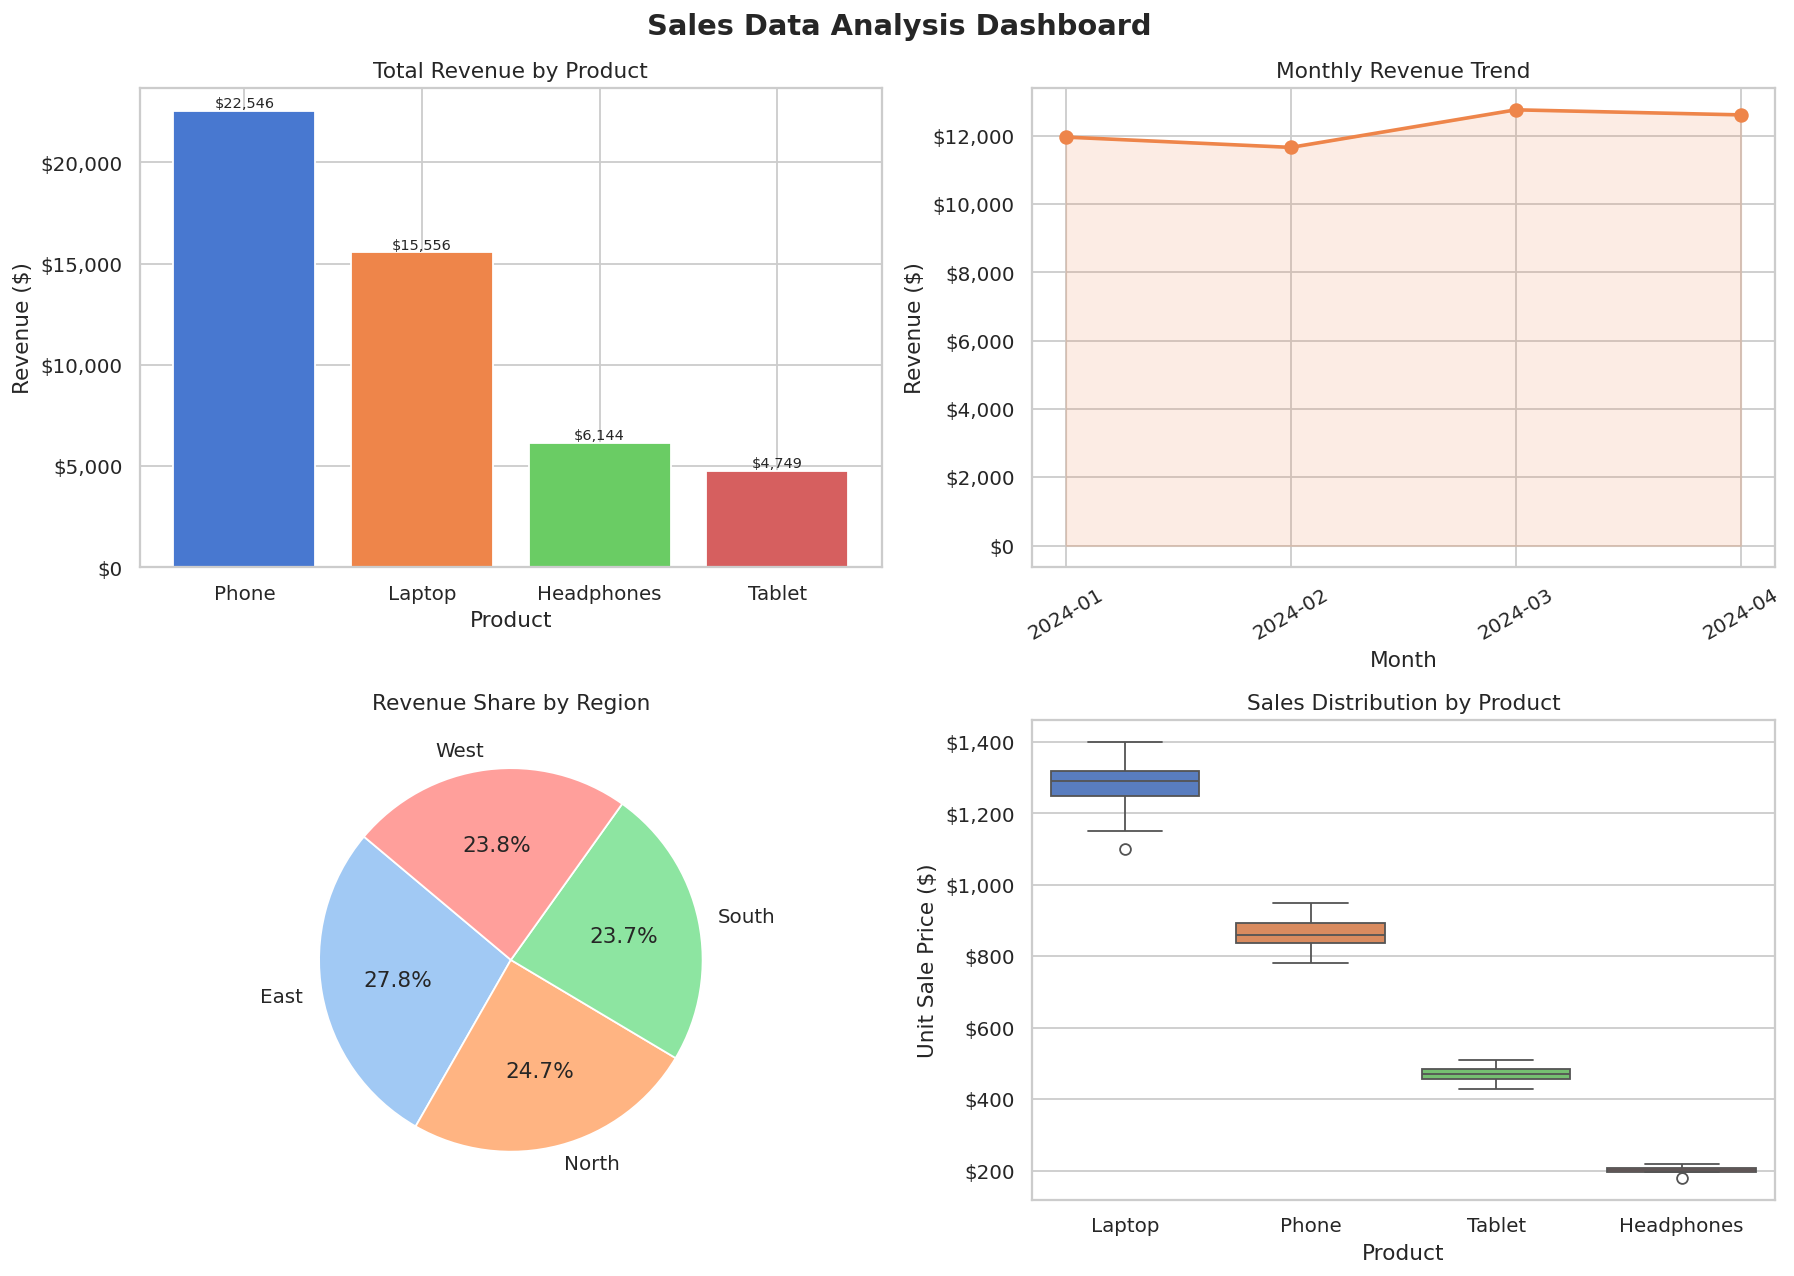

  ✔  Dashboard saved → /kaggle/working/charts/dashboard.png


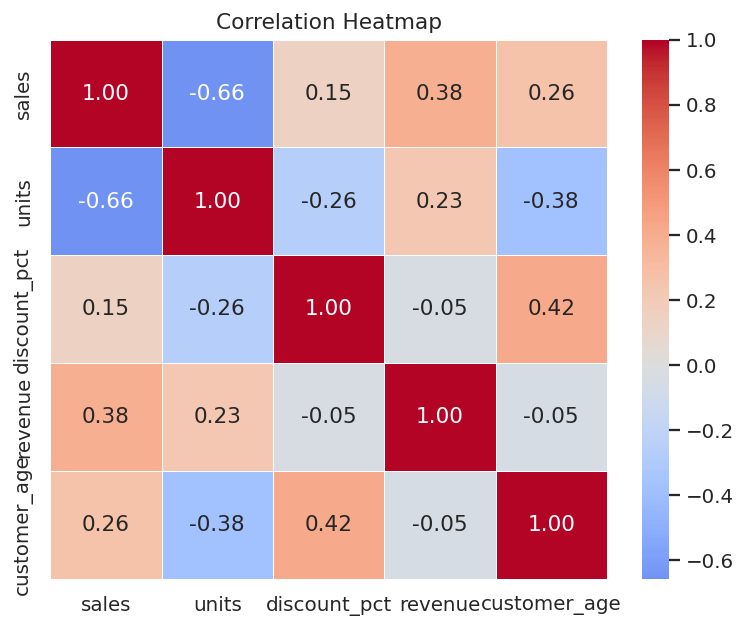

  ✔  Heatmap saved → /kaggle/working/charts/correlation_heatmap.png

  ✅  Analysis complete!  Charts in /kaggle/working/charts/



In [13]:
#  MAIN 
def main():
    df = load_data()          # ← no filepath argument needed
    df = clean_data(df)
    summary_statistics(df)
    create_charts(df)
    print("\n" + "=" * 55)
    print("  ✅  Analysis complete!  Charts in /kaggle/working/charts/")
    print("=" * 55 + "\n")

if __name__ == "__main__":
    main()